# Random Forest Modeling

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import sys
import os

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)

from data_creator import load_2D
df = load_2D().drop("PID", axis = 1).dropna() # load data from files

# split data into X and y

X = df[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]]
y = df["AD"] > df["ADPass"]

# scale X
scale = StandardScaler()
scaled_X = scale.fit_transform(X)

# train test split
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 4)

/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset
Total gantry area:  181    247.225
183    262.010
185    264.020
187    262.215
189    260.390
        ...   
63     107.405
65     119.975
67     132.105
69     132.070
70     126.670
Length: 126, dtype: float64
Total gantry area:  179     57.505
177     64.885
175     64.915
173     62.555
171     65.020
        ...   
189    103.820
187    101.705
185     96.390
183     90.720
181     81.395
Length: 180, dtype: float64
Total gantry area:  179    8.380
177    9.605
175    8.945
173    8.415
171    8.255
       ...  
189    7.930
187    7.980
185    8.105
183    8.115
181    7.630
Length: 180, dtype: float64
Total gantry area:  181    295.940
183    303.565
185    292.835
187    274.255
189    251.340
        ...   
171    266.560
173    250.880
175    223.855
177    203.335
179    182.405
Length: 180, dtype: float64
Total gantry area:  179    36.535
177    38.240
175    38.035
173    39.470
17

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# initialize random forest classifier
rfc = RandomForestClassifier()

# tune random forest parameters
param_grid = {
    'n_estimators':[5,10,15,20],
    'max_depth':[2,5,7,9]
}
grid_clf = GridSearchCV(rfc, param_grid, cv=10)
grid_clf.fit(X_train, y_train)

# fit final random forest model
final = RandomForestClassifier(n_estimators = grid_clf.best_params_["n_estimators"],
 max_depth = grid_clf.best_params_["max_depth"])
final.fit(X_train, y_train)

RandomForestClassifier(max_depth=9, n_estimators=10)

### Results

Training ROC AUC 0.9492047807265198


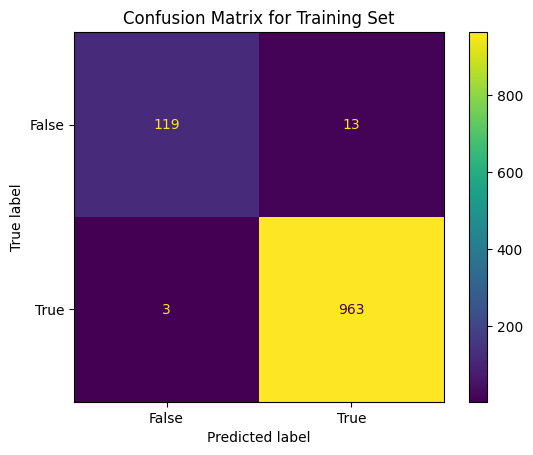

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

pred_rf = final.predict(X_train)

print("Training ROC AUC", roc_auc_score(y_train, pred_rf))
cm1 = ConfusionMatrixDisplay.from_predictions(y_train, pred_rf)
cm1.ax_.set_title("Confusion Matrix for Training Set")
plt.show()

Testing ROC AUC 0.8149762624082866


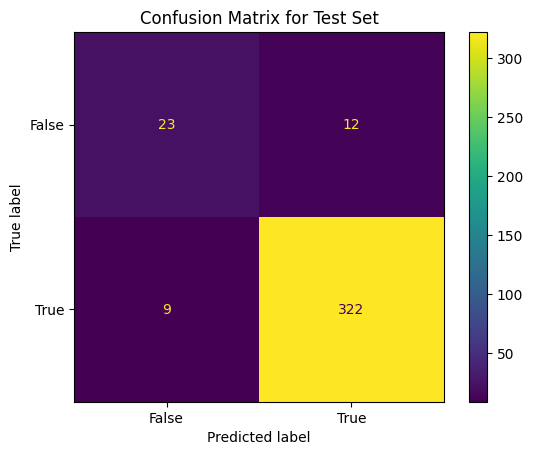

In [4]:

rfc = RandomForestClassifier(n_estimators=10, max_depth=2)
rfc.fit(X_train, y_train)

pred_rf = final.predict(X_test)

print("Testing ROC AUC", roc_auc_score(y_test, pred_rf))
cm1 = ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
cm1.ax_.set_title("Confusion Matrix for Test Set")
plt.show()

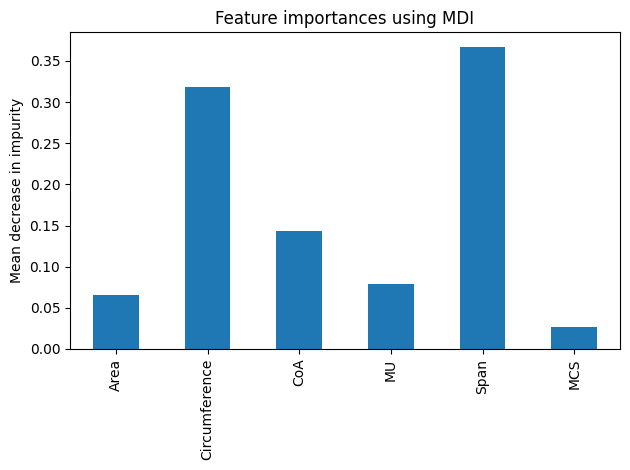

In [6]:
# Feature Importance
feature_names = X.columns
importances = rfc.feature_importances_

import pandas as pd

forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()